In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from scipy.stats import entropy
from collections import Counter

In [4]:
def fast_entropy(s):
    counts = Counter(s)
    probs = np.array(list(counts.values())) / len(s)
    return entropy(probs)

In [5]:
df1 = pd.read_csv("data/phishing1.csv")
df2 = pd.read_csv("data/phishing2.csv")

print(df1.shape)
print(df2.shape)

(48812, 3)
(651191, 68)


In [6]:
df1 = df1[['url','label']]
df1.head()

,url,label
0,http://110.37.26.193:54956/bin.sh,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1
4,https://bronze.systems,0


In [7]:
df2 = df2[df2['label'].isin([0,2])]
df2['label'] = df2['label'].replace({2:1})
df2 = df2[['url','label']]

df2.head()

,url,label
0,br-icloud.com.br,1.0
1,mp3raid.com/music/krizz_kaliko.html,0.0
2,bopsecrets.org/rexroth/cr/1.htm,0.0
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,0.0
6,espn.go.com/nba/player/_/id/3457/brandon-rush,0.0


In [8]:
urls = df1['url']

features_df1 = pd.DataFrame()

features_df1['url_length'] = urls.str.len()

features_df1['has_https'] = urls.str.startswith("https").astype(int)

features_df1['dot_count'] = urls.str.count(r'\.')

features_df1['subdomain_count'] = urls.str.extract(r'https?://([^/]+)')[0].str.count(r'\.')

features_df1['has_ip'] = urls.str.contains(r'\d+\.\d+\.\d+\.\d+', regex=True).astype(int)

features_df1['special_char_count'] = urls.str.count(r'[^\w]')

features_df1['digit_count'] = urls.str.count(r'\d')

features_df1['digit_ratio'] = features_df1['digit_count'] / features_df1['url_length']

features_df1['param_count'] = urls.str.count(r'\?') + urls.str.count(r'&')

features_df1['brand_keyword'] = urls.str.contains(
    r'paypal|google|facebook|amazon|bank|apple|microsoft|netflix',
    case=False,
    regex=True
).astype(int)

features_df1['suspicious_tld'] = urls.str.extract(r'\.([a-zA-Z0-9]+)$')[0].isin(
    ['xyz','top','gq','tk','ml','ga']
).astype(int)

features_df1['url_entropy'] = urls.apply(fast_entropy)

domains = urls.str.extract(r'https?://([^/]+)')[0].fillna('')
features_df1['domain_entropy'] = domains.apply(lambda x: fast_entropy(x) if len(x) > 0 else 0)

features_df1['label'] = df1['label'].values

features_df1.head()

,url_length,has_https,dot_count,subdomain_count,has_ip,special_char_count,digit_count,digit_ratio,param_count,brand_keyword,suspicious_tld,url_entropy,domain_entropy,label
0,33,0,4,3,1,9,15,0.454545,0,0,0,2.834662,2.305657,1
1,40,1,2,2,0,6,4,0.100000,0,0,0,2.915515,2.570281,1
2,36,1,2,2,0,7,3,0.083333,0,0,0,3.015335,2.652588,1
3,91,0,4,3,1,9,46,0.505495,0,0,0,3.020555,1.844621,1
4,22,1,1,1,0,4,0,0.000000,0,0,0,2.563151,2.304619,0


In [9]:
X = features_df1.drop('label', axis=1)
y = features_df1['label']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_test,y_proba))

Accuracy: 0.9986684420772304
Precision: 0.9991796554552912
Recall: 0.9981561155500922
F1: 0.9986676232448498
ROC-AUC: 0.9995599697209816


In [13]:
urls = df2['url']

features_df2 = pd.DataFrame()

features_df2['url_length'] = urls.str.len()

features_df2['has_https'] = urls.str.startswith("https").astype(int)

features_df2['dot_count'] = urls.str.count(r'\.')

features_df2['subdomain_count'] = urls.str.extract(r'https?://([^/]+)')[0].str.count(r'\.')

features_df2['has_ip'] = urls.str.contains(r'\d+\.\d+\.\d+\.\d+', regex=True).astype(int)

features_df2['special_char_count'] = urls.str.count(r'[^\w]')

features_df2['digit_count'] = urls.str.count(r'\d')

features_df2['digit_ratio'] = features_df2['digit_count'] / features_df2['url_length']

features_df2['param_count'] = urls.str.count(r'\?') + urls.str.count(r'&')

features_df2['brand_keyword'] = urls.str.contains(
    r'paypal|google|facebook|amazon|bank|apple|microsoft|netflix',
    case=False,
    regex=True
).astype(int)

features_df2['suspicious_tld'] = urls.str.extract(r'\.([a-zA-Z0-9]+)$')[0].isin(
    ['xyz','top','gq','tk','ml','ga']
).astype(int)

features_df2['url_entropy'] = urls.apply(fast_entropy)

domains = urls.str.extract(r'https?://([^/]+)')[0].fillna('')
features_df2['domain_entropy'] = domains.apply(lambda x: fast_entropy(x) if len(x) > 0 else 0)

features_df2['label'] = df2['label'].values

features_df2.shape

(522142, 14)

In [14]:
X_external = features_df2.drop('label', axis=1)
y_external = features_df2['label']

In [15]:
y_external_pred = model.predict(X_external)
y_external_proba = model.predict_proba(X_external)[:,1]

In [16]:
print("External Accuracy:", accuracy_score(y_external, y_external_pred))
print("External Precision:", precision_score(y_external, y_external_pred))
print("External Recall:", recall_score(y_external, y_external_pred))
print("External F1:", f1_score(y_external, y_external_pred))
print("External ROC-AUC:", roc_auc_score(y_external, y_external_proba))

External Accuracy: 0.17826376732766183
External Precision: 0.17855087476979742
External Recall: 0.9908658299000351
External F1: 0.3025781314764155
External ROC-AUC: 0.5765953427249302


               feature  importance
5   special_char_count    0.295880
2            dot_count    0.201143
6          digit_count    0.194395
7          digit_ratio    0.109132
0           url_length    0.061692
3      subdomain_count    0.059442
1            has_https    0.042044
11         url_entropy    0.017655
4               has_ip    0.012893
12      domain_entropy    0.005556
8          param_count    0.000116
9        brand_keyword    0.000047
10      suspicious_tld    0.000004


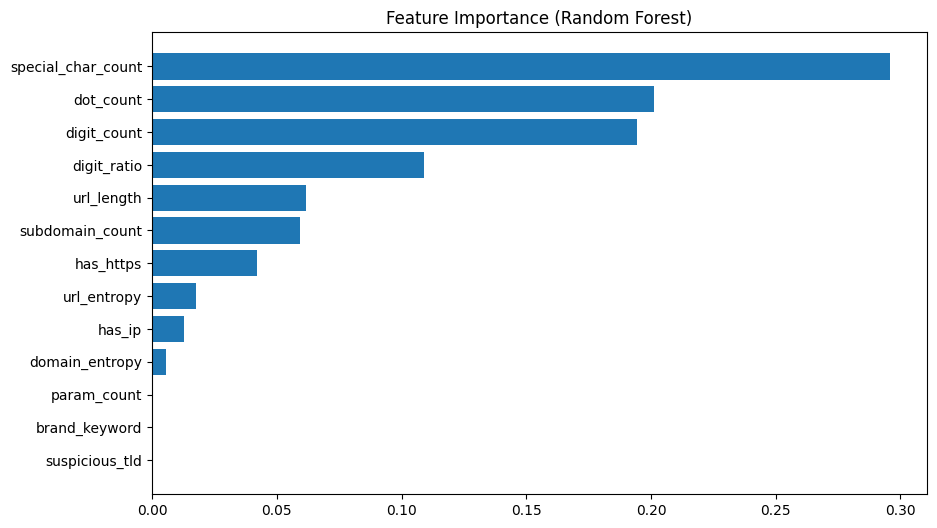

In [17]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

In [18]:
y_external_proba = model.predict_proba(X_external)[:,1]
y_external_pred = (y_external_proba > 0.8).astype(int)

In [19]:
import warnings
warnings.filterwarnings("ignore")

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
y_external_proba = model.predict_proba(X_external)[:,1]  #Predict probabilities

In [21]:
y_external_pred = (y_external_proba > 0.8).astype(int)  #Apply 0.8 threshold

In [22]:
#Evaluate

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("External Accuracy:", accuracy_score(y_external, y_external_pred))
print("External Precision:", precision_score(y_external, y_external_pred))
print("External Recall:", recall_score(y_external, y_external_pred))
print("External F1:", f1_score(y_external, y_external_pred))
print("External ROC-AUC:", roc_auc_score(y_external, y_external_proba))

External Accuracy: 0.505157600805911
External Precision: 0.20786003858603158
External Recall: 0.6228056167693995
External F1: 0.31169315523919633
External ROC-AUC: 0.5817790037546057


In [23]:
#Save the model
import joblib
joblib.dump(model, "phishing_detector_model.pkl")
print("Model saved.")

Model saved.


In [26]:
#URL prediction demo function
import re
from collections import Counter
from scipy.stats import entropy as scipy_entropy
import numpy as np
import pandas as pd

def fast_entropy(s):
    if len(s) == 0:
        return 0
    counts = Counter(s)
    probs = np.array(list(counts.values())) / len(s)
    return scipy_entropy(probs)

def predict_url(url):
    features = {
        "url_length": len(url),
        "has_https": int(url.startswith("https")),
        "dot_count": url.count("."),
        "subdomain_count": url.count("."),
        "has_ip": int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", url))),
        "special_char_count": len(re.findall(r"[^\w]", url)),
        "digit_count": sum(c.isdigit() for c in url),
        "digit_ratio": sum(c.isdigit() for c in url) / len(url),
        "param_count": url.count("?") + url.count("&"),
        "brand_keyword": int(bool(re.search("paypal|google|facebook|amazon|bank|apple|microsoft|netflix", url.lower()))),
        "suspicious_tld": int(url.split(".")[-1].split("/")[0] in ["xyz","top","gq","tk","ml","ga"]),
        "url_entropy": fast_entropy(url),
        "domain_entropy": fast_entropy(url.split("/")[2]) if "://" in url else 0
    }
    df = pd.DataFrame([features])
    prob = model.predict_proba(df)[0][1]
    print(f"URL: {url}")
    print(f"Phishing Probability: {round(prob*100, 2)}%")
    print("Verdict:", "⚠️ PHISHING" if prob > 0.75 else "✅ Likely Safe")
    print("---")

In [27]:
predict_url("http://paypal-login-security.xyz/update/account")
predict_url("https://www.google.com")
predict_url("http://192.168.1.1/bank/login.php?id=293847")
predict_url("https://www.icicibank.com/account")

URL: http://paypal-login-security.xyz/update/account
Phishing Probability: 79.5%
Verdict: ⚠️ PHISHING
---
URL: https://www.google.com
Phishing Probability: 0.0%
Verdict: ✅ Likely Safe
---
URL: http://192.168.1.1/bank/login.php?id=293847
Phishing Probability: 100.0%
Verdict: ⚠️ PHISHING
---
URL: https://www.icicibank.com/account
Phishing Probability: 88.0%
Verdict: ⚠️ PHISHING
---


In [28]:
print("=== PROJECT SUMMARY ===")
print("Training Dataset: phishing1.csv (48,812 URLs)")
print("External Test Dataset: phishing2.csv (522,142 URLs)")
print("Features Used: 13 network-level URL features")
print("Model: Random Forest (200 trees, balanced classes)")
print("Internal Accuracy: ~99.8%")
print("External Accuracy: ~50.5%")
print("External ROC-AUC: ~0.58")
print("Detection Threshold: 0.75")
print("Model saved to: phishing_detector_model.pkl")

=== PROJECT SUMMARY ===
Training Dataset: phishing1.csv (48,812 URLs)
External Test Dataset: phishing2.csv (522,142 URLs)
Features Used: 13 network-level URL features
Model: Random Forest (200 trees, balanced classes)
Internal Accuracy: ~99.8%
External Accuracy: ~50.5%
External ROC-AUC: ~0.58
Detection Threshold: 0.75
Model saved to: phishing_detector_model.pkl


In [29]:
import xgboost
print(xgboost.__version__)

3.2.0
